**Feature Selection**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [22]:
df = pd.read_csv('/content/pca_transformed_data.csv')

Feature Importance (Random Forest)

Feature Importances (Random Forest):
PC_1     0.389613
PC_6     0.081976
PC_4     0.072642
PC_2     0.062649
PC_9     0.054529
PC_8     0.054466
PC_10    0.052088
PC_12    0.051525
PC_7     0.047201
PC_3     0.047168
PC_11    0.044683
PC_5     0.041459
dtype: float64


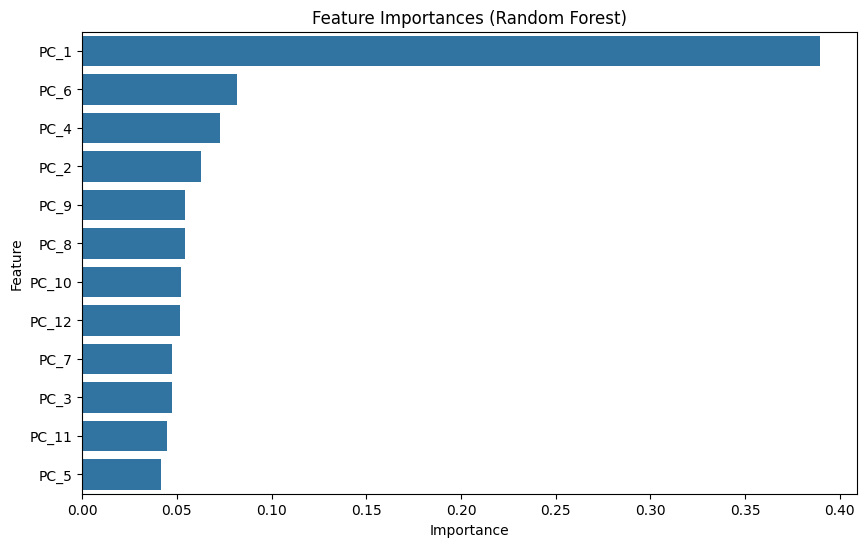

In [23]:
X = df.drop('num', axis=1)
y = df['num']

# Train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Get feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns)

# Sort feature importances in descending order
sorted_feature_importances = feature_importances.sort_values(ascending=False)

# Print the ranked feature importances
print("Feature Importances (Random Forest):")
print(sorted_feature_importances)

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_feature_importances, y=sorted_feature_importances.index)
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Recursive Feature Elimination (RFE) to select the best predictors

In [24]:
from sklearn.feature_selection import RFE

# Initialize RFE with the Random Forest model and specify the number of features to select
# You can change n_features_to_select to the desired number of top features
n_features_to_select = 10
rfe = RFE(estimator=model, n_features_to_select=n_features_to_select)

# Fit RFE on the data
rfe.fit(X, y)

# Get the selected features
selected_features_rfe = X.columns[rfe.support_]

print(f"\nFeatures selected by RFE ({n_features_to_select} features):")
print(selected_features_rfe)

# You can also get the ranking of features
print("\nFeature Ranking by RFE:")
print(rfe.ranking_)


Features selected by RFE (10 features):
Index(['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10',
       'PC_12'],
      dtype='object')

Feature Ranking by RFE:
[1 1 1 1 3 1 1 1 1 1 2 1]


In [35]:
# Create a new DataFrame with only the selected PCA features and the target variable
pca_selected = X[selected_features_rfe].copy()
pca_selected['num'] = y

print("Shape of the original PCA data:", X.shape)
print("Shape of the selected PCA features DataFrame with target:", pca_selected.shape)
pca_selected.head()

# Save the DataFrame to a CSV file
pca_selected.to_csv('pca_selected.csv', index=False)

Shape of the original PCA data: (303, 12)
Shape of the selected PCA features DataFrame with target: (303, 11)


In [36]:
# from google.colab import files
# files.download('pca_selected.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

let's try the same thing on clean_data

In [26]:
clead_df = pd.read_csv('/content/clean_data.csv')

In [27]:
X_clean = clead_df.drop('num', axis=1)
y_clean = clead_df['num']

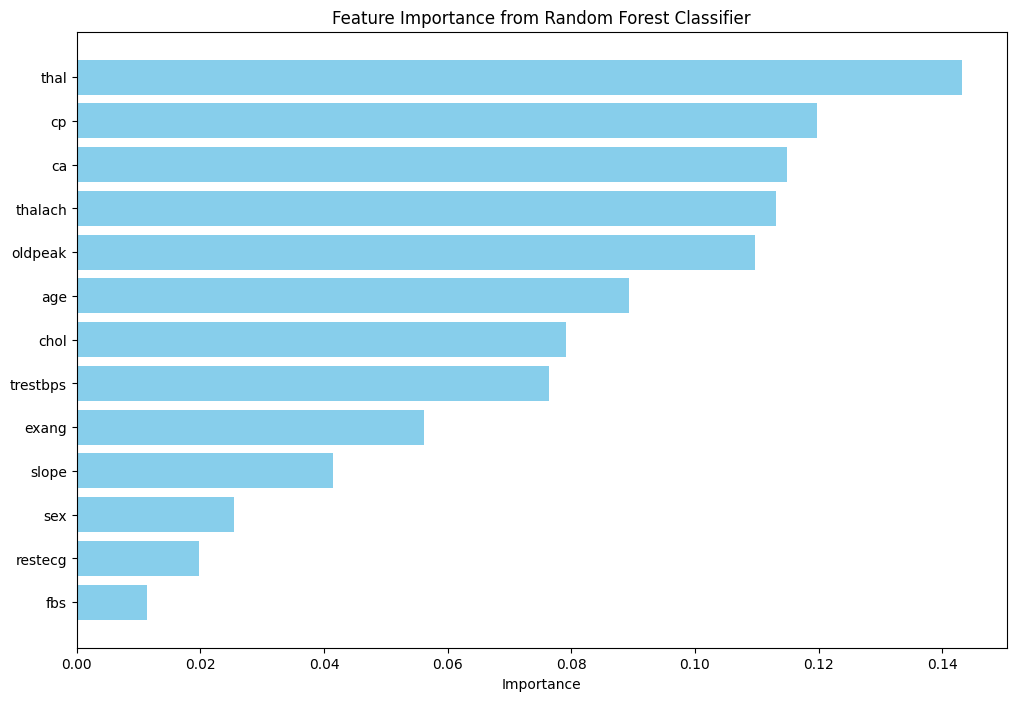

In [28]:
model_cleandf = RandomForestClassifier()
model_cleandf.fit(X_clean, y_clean)
importances = model_cleandf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_clean.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance from Random Forest Classifier')
plt.gca().invert_yaxis()
plt.show()

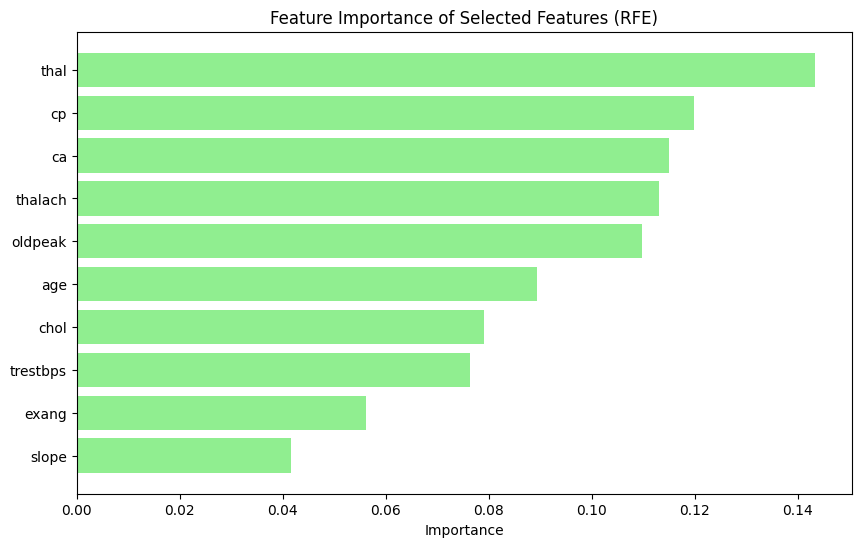

In [29]:
selector = RFE(estimator=model_cleandf, n_features_to_select=n_features_to_select)
selector.fit(X_clean, y_clean)
selected_features = X_clean.columns[selector.support_]
importances = model_cleandf.feature_importances_
importance_df = pd.DataFrame({'Feature': X_clean.columns, 'Importance': importances})
importance_df = importance_df[importance_df['Feature'].isin(selected_features)].sort_values(by='Importance',
                                                                                            ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='lightgreen')
plt.xlabel('Importance')
plt.title('Feature Importance of Selected Features (RFE)')
plt.gca().invert_yaxis()
plt.show()

In [30]:
importance_df['Feature']

,Feature
12,thal
2,cp
11,ca
7,thalach
9,oldpeak
0,age
4,chol
3,trestbps
8,exang
10,slope


In [38]:
rfe = clead_df[importance_df['Feature']].copy()
rfe['num'] = clead_df['num']
rfe.to_csv('features_selected_rfe.csv',index=False)

In [40]:
files.download('features_selected_rfe.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>